# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [49]:
# Your comment here

#I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [50]:
# Your code here 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [51]:
# Your code here
g = 9.8 #m/s^2
L = 1.0 #m

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [52]:
# Your code here

def pendulum(t, y):
    theta, omega = y # y[0] = theta, y[1] = omega
    dtheta_dt = omega
    d_omega_dt = - (g / L)* np.sin(theta)
    return [dtheta_dt, d_omega_dt]

Give you equation some initial conditions. Run the cell below.

In [53]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [54]:
# Your code here
t_span = (0,10)
t_eval = np.linspace(0,10,500)
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval = t_eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [55]:
# Your code here
theta_values = sol.y[0]
time_values = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [56]:
# Your code here
theoretical_period = 2 * np.pi * np.sqrt(L / g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [57]:
# Your code here

print(f"Theoretical period: {theoretical_period:.2g} seconds")

Theoretical period: 2 seconds


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [58]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

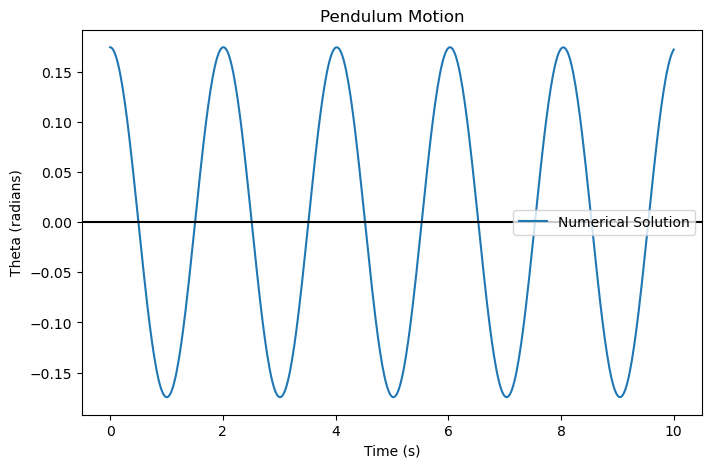

In [59]:
# Your code here
plt.figure(figsize=(8, 5))
plt.plot(time_values, theta_values, label="Numerical Solution")

plt.axhline(0, color = 'black', linestyle="-")

plt.xlabel("Time (s)")
plt.ylabel("Theta (radians)")
plt.title("Pendulum Motion")
plt.legend()
plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [60]:
# Your code here'

print(f"Numerical period: {T_numerical:.4g} seconds")

Numerical period: 2.004 seconds


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [61]:
# Your comment here

percentage_error = abs((T_numerical - theoretical_period) / theoretical_period) * 100
print(f"Percent diff: {percentage_error:.2f}%")

Percent diff: 0.15%


## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [62]:
# Your code here
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [63]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [64]:
# Your code here

df = pd.read_csv(url)

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [65]:
# Your code here

df_country = df[df["location"] == "United States"]

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [66]:
# Your code here
df_country = df_country[["date", "total_cases"]].dropna()
df_country["days since start"] = range(len(df_country))

Print the first few rows of your `df_country` dataframe.

In [67]:
# Your code here

df_country.head()

,date,total_cases,days since start
403451,2020-01-05,0.0,0
403452,2020-01-06,0.0,1
403453,2020-01-07,0.0,2
403454,2020-01-08,0.0,3
403455,2020-01-09,0.0,4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [68]:
# Your code here
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [69]:
# Your code here

def exponential_growth(t, C_0, r):
    return C_0 * np.exp(r*t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [70]:
# Your code here
days = df_country["days since start"].iloc[:30]  
cases = df_country["total_cases"].iloc[:30]

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [71]:
# Your code here
popt, pcov = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [72]:
# Your code here
C0_fit, r_fit = popt

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [73]:
# Your code here
print(f"C0: {C0_fit:.2g}")  
print(f"r: {r_fit:.4f}")  

C0: 0.12
r: 0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [74]:
# Your code here
future_days = np.arange(0, 61)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [75]:
# Your code here 
predicted_cases = exponential_growth(future_days, *popt)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

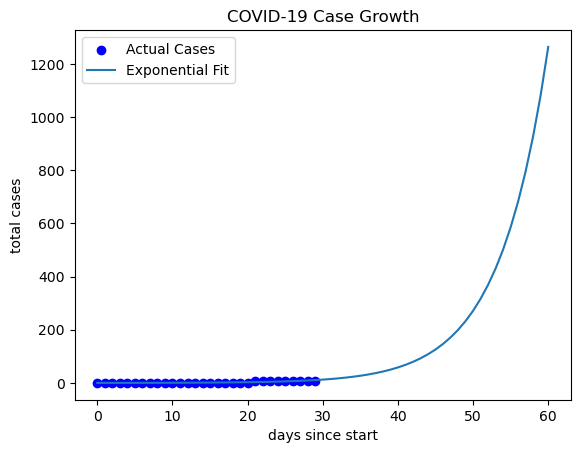

In [76]:
# Your code here
plt.scatter(days, cases, label="Actual Cases", color="blue", marker="o")

plt.plot(future_days, predicted_cases, label="Exponential Fit")

plt.xlabel("days since start")
plt.ylabel("total cases")
plt.title("COVID-19 Case Growth")

plt.legend()
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [77]:
# Your comment here

y_actual = cases 
y_predicted = exponential_growth(days, *popt)  
y_mean = np.mean(y_actual)  

ss_total = np.sum((y_actual - y_mean) ** 2)  
ss_residual = np.sum((y_actual - y_predicted) ** 2) 

r_squared = 1 - (ss_residual / ss_total)

print(f"r^2 value: {r_squared:.4f}")

#the r^2 value is 0.80 which is pretty close to 1, therefore the fit is good but has some error.


r^2 value: 0.8022


Make another plot but this time to **90 days**.

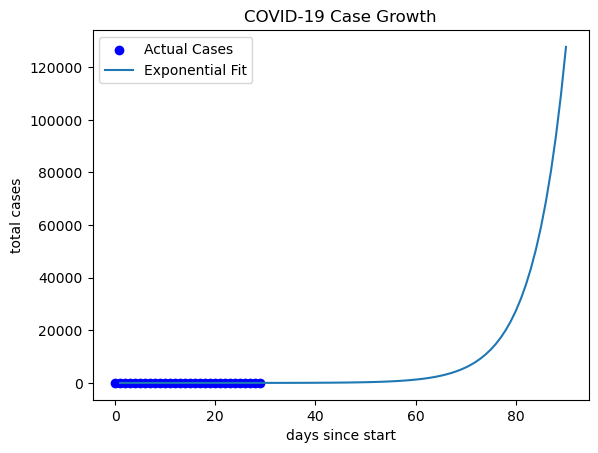

In [78]:
# Your code here
more_future_days = np.arange(1,91)
predicted_cases_longer = exponential_growth(more_future_days, *popt)

plt.scatter(days, cases, label="Actual Cases", color="blue", marker="o")

plt.plot(more_future_days, predicted_cases_longer, label="Exponential Fit")

plt.xlabel("days since start")
plt.ylabel("total cases")
plt.title("COVID-19 Case Growth")

plt.legend()
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [79]:
# Your code here

predicted_cases_87 = exponential_growth(87, *popt)
print(f"Predicted cases, day 87: {predicted_cases_87:.0f}")

Predicted cases, day 87: 80497


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

/var/folders/t4/tsr_bxjd4yx7wfsg954svp6w0000gp/T/ipykernel_33519/852557477.py:8: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df.pivot("month", "year", "passengers")


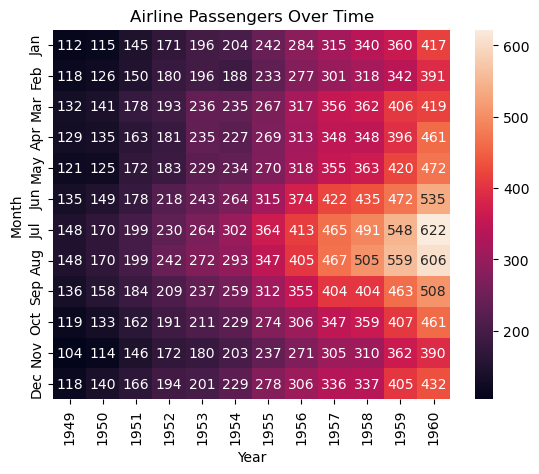

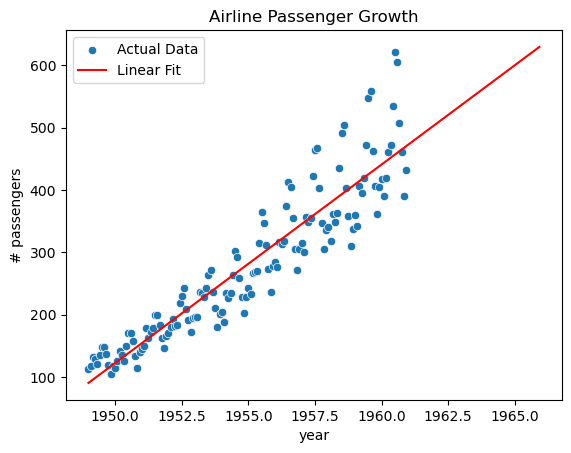

In [81]:

# Your code here

import seaborn as sns

df = sns.load_dataset("flights")

#heat map
df_pivot = df.pivot("month", "year", "passengers")

sns.heatmap(df_pivot, annot=True, fmt="d")

plt.xlabel("Year")
plt.ylabel("Month")
plt.title("Airline Passengers Over Time")

plt.show()

#fit to linear model + predict next 5 years

df["time"] = df["year"] + (df["month"].astype("category").cat.codes / 12) # create numerical time

def linear_model(x, m, b):
    return m * x + b

popt, cov = curve_fit(linear_model, df["time"], df["passengers"], p0=[100, 0.1])

time_vals = np.linspace(df["time"].min(), df["time"].max() + 5, 100)
passenger_preds = linear_model(time_vals, *popt)

sns.scatterplot(x=df["time"], y=df["passengers"], label="Actual Data")
plt.plot(time_vals, passenger_preds, color="red", label="Linear Fit")
plt.xlabel("year")
plt.ylabel("# passengers")
plt.title("Airline Passenger Growth")
plt.legend()
plt.show()


On it's own branch, submit this notebook to Gradescope! 